Install & Import Library

In [1]:
!pip install ultralytics scikit-learn imbalanced-learn seaborn matplotlib tensorflow joblib

import os
import re
import csv
import pandas as pd
import numpy as np
from google.colab import drive
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import joblib

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Mount Google Drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


Filter File YOLO & Ambil Probabilitas

In [5]:
YOLO_MODEL_PATH = "/content/drive/MyDrive/PhysioAnx/resource/yolomodel.pt"
yolo_model = YOLO(YOLO_MODEL_PATH)

images_dir = "/content/drive/MyDrive/PhysioAnx/DATASETYOLO/images"
labels_dir = "/content/drive/MyDrive/PhysioAnx/DATASETYOLO/labels"

# ==============================
# STEP 3: Filter File YOLO sebelum prediksi (hapus Kaggle)
# ==============================
def filter_files_yolo(files):
    kept = []
    for f in files:
        m = re.match(r'([A-Z]+)-\((\d+)\)\.png', f)
        if not m: continue
        prefix, num = m.group(1), int(m.group(2))
        # Aturan filter Kaggle
        if prefix == 'A' and 378 <= num <= 411: continue
        if prefix == 'ES' and 241 <= num <= 259: continue
        if prefix == 'D' and 272 <= num <= 335: continue
        if prefix == 'N' and (241 <= num <= 274 or 338 <= num <= 354 or 414 <= num <= 509): continue
        kept.append(f)
    return kept

all_images = [f for f in os.listdir(images_dir) if f.endswith('.png')]
filtered_images = filter_files_yolo(all_images)
print("Jumlah file YOLO setelah filter:", len(filtered_images))

# ==============================
# STEP 3b: Ambil probabilitas hanya untuk file yang sudah difilter
# ==============================
def get_probs_yolo_detect(image_path, num_classes=4):
    results = yolo_model.predict(image_path, save=False, verbose=False, conf=0.25)[0]
    boxes = results.boxes
    vec = np.zeros(num_classes, dtype=np.float32)
    if boxes is not None and boxes.cls is not None:
        classes = boxes.cls.cpu().numpy().astype(int)
        confs = boxes.conf.cpu().numpy()
        for c, s in zip(classes, confs):
            if 0 <= c < num_classes:
                vec[c] += s
    if vec.sum() > 0:
        exp_vec = np.exp(vec)
        probs = exp_vec / exp_vec.sum()
    else:
        probs = np.ones(num_classes) / num_classes
    return probs

def get_label_from_txt(txt_path):
    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            line = f.readline().strip().split()
            if len(line) > 0:
                return int(line[0])
    return -1

records = []
for fname in sorted(filtered_images):
    img_path = os.path.join(images_dir, fname)
    label_path = os.path.join(labels_dir, os.path.splitext(fname)[0] + ".txt")
    probs = get_probs_yolo_detect(img_path, num_classes=4)
    label = get_label_from_txt(label_path)
    records.append([fname] + probs.tolist() + [label])

df_yolo = pd.DataFrame(records, columns=["filename", "prob_class0", "prob_class1", "prob_class2", "prob_class3", "label"])

Jumlah file YOLO setelah filter: 835


Merge YOLO dengan Mapping Nama

In [ ]:
mapping_path = "/content/drive/MyDrive/PhysioAnx/path_ke_output/mapping_nama.csv"
mapping = pd.read_csv(mapping_path)

# Pastikan folder output ada
out_dir = "/content/drive/MyDrive/PhysioAnx/path_ke_output"
os.makedirs(out_dir, exist_ok=True)

# ==============================
# Merge YOLO probabilitas dengan mapping
# ==============================
# only keep rows where filename exists in mapping
yolo_merged = pd.merge(mapping, df_yolo, left_on="Format YOLO", right_on="filename", how="inner")

# Urutkan kolom
cols = ["Nama", "Format YOLO", "Label YOLO", "filename",
        "prob_class0","prob_class1","prob_class2","prob_class3","label"]
yolo_merged = yolo_merged[cols]

# Buang baris tanpa Nama (NaN)
yolo_merged = yolo_merged.dropna(subset=["Nama"])

Load DNN Model & Ambil Probabilitas

In [ ]:
DNN_MODEL_PATH = "/content/drive/MyDrive/PhysioAnx/resource/dnnmodel.h5"
SCALER_PATH = "/content/drive/MyDrive/PhysioAnx/resource/scaler_joblibfold2.pkl"
DATASET_DNN_CSV = "/content/drive/MyDrive/PhysioAnx/resource/databersih3.csv"

dnn_model = load_model(DNN_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
dnn_model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

df_dnn = pd.read_csv(DATASET_DNN_CSV)
label_map = {"normal to mild":0,"mild to moderate":1,"moderate to severe":2,"severe":3}
df_dnn["label"] = df_dnn["KELAS"].map(label_map)

X_dnn = df_dnn[["HR","ST","GSR"]].values
X_scaled = scaler.transform(X_dnn)
y_dnn = df_dnn["label"].values
y_cat = to_categorical(y_dnn, num_classes=4)

loss, acc = dnn_model.evaluate(X_scaled, y_cat, verbose=1)
print("DNN Loss:", loss, "Accuracy:", acc)

probs_dnn = dnn_model.predict(X_scaled)
probs_df_dnn = pd.DataFrame(probs_dnn, columns=[f"prob_class{i}" for i in range(4)])
df_out_dnn = pd.concat([df_dnn[["Nama","KELAS"]].reset_index(drop=True), probs_df_dnn], axis=1)
df_out_dnn["label"] = y_dnn

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9996 - loss: 0.0020
DNN Loss: 0.00704119773581624 Accuracy: 0.9967319965362549
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Average Probabilitas per Nama & Fusion

In [6]:
dnn_path = "/content/drive/MyDrive/PhysioAnx/path_ke_output/dnnprobslabeled2.xlsx"
yolo_path = "/content/drive/MyDrive/PhysioAnx/path_ke_output/yoloprobswithnames2.xlsx"

# Load Excel
dnn_df = pd.read_excel(dnn_path)
yolo_df = pd.read_excel(yolo_path)

# YOLO average per Nama
yolo_avg = yolo_df.groupby("Nama")[["prob_class0","prob_class1","prob_class2","prob_class3"]].mean()

# DNN average per Nama
dnn_avg = dnn_df.groupby("Nama")[["prob_class0","prob_class1","prob_class2","prob_class3"]].mean()

# Ambil label dari DNN (anggap label di DNN lebih "ground truth")
dnn_labels = dnn_df.groupby("Nama")["label"].first()

# Sinkronisasi nama yang sama
common_names = yolo_avg.index.intersection(dnn_avg.index)

fusion_df = pd.concat([
    yolo_avg.loc[common_names].add_prefix("yolo_"),
    dnn_avg.loc[common_names].add_prefix("dnn_")
], axis=1)

fusion_df["label"] = dnn_labels.loc[common_names]

# Setelah fusion_df["label"] = dnn_labels.loc[common_names]

# ==============================
# Tambahkan deteksi unknown
# ==============================
fusion_df["detected_flag"] = "detected"  # default

yolo_cols = ["yolo_prob_class0","yolo_prob_class1","yolo_prob_class2","yolo_prob_class3"]
dnn_cols  = ["dnn_prob_class0","dnn_prob_class1","dnn_prob_class2","dnn_prob_class3"]

for i, row in fusion_df.iterrows():
    y_detect = row[yolo_cols].sum() == 0
    d_detect = row[dnn_cols].sum() == 0

    if y_detect and d_detect:
        fusion_df.loc[i, "detected_flag"] = "unknown"
    elif y_detect:
        fusion_df.loc[i, "detected_flag"] = "unknown_face"
    elif d_detect:
        fusion_df.loc[i, "detected_flag"] = "unknown_sensor"

Train/Test Split + SMOTE + Random Forest

In [8]:
from collections import Counter


# Features dan target
feature_cols = [col for col in fusion_df.columns if 'prob' in col]
X = fusion_df[feature_cols]
y = fusion_df["label"]

# Split train/test dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cek jumlah sampel per kelas
class_counts = Counter(y_train)
print("Jumlah sampel per kelas sebelum SMOTE:", class_counts)

# Tentukan k_neighbors SMOTE yang aman
min_samples = min(class_counts.values())
k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1
print("k_neighbors untuk SMOTE:", k_neighbors)

# Oversampling dengan SMOTE
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Jumlah sampel per kelas setelah SMOTE:", Counter(y_train_res))

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_res, y_train_res)

Jumlah sampel per kelas sebelum SMOTE: Counter({0: 37, 1: 17, 3: 9, 2: 5})
k_neighbors untuk SMOTE: 4
Jumlah sampel per kelas setelah SMOTE: Counter({0: 37, 1: 37, 2: 37, 3: 37})


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Evaluasi Random Forest


--- Metrics Train Set ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        37
           1     1.0000    1.0000    1.0000        37
           2     1.0000    1.0000    1.0000        37
           3     1.0000    1.0000    1.0000        37

    accuracy                         1.0000       148
   macro avg     1.0000    1.0000    1.0000       148
weighted avg     1.0000    1.0000    1.0000       148



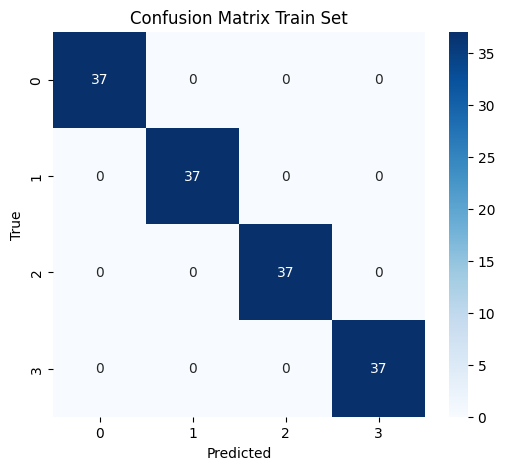


--- Metrics Test Set ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000         4
           2     1.0000    1.0000    1.0000         1
           3     1.0000    1.0000    1.0000         3

    accuracy                         1.0000        18
   macro avg     1.0000    1.0000    1.0000        18
weighted avg     1.0000    1.0000    1.0000        18



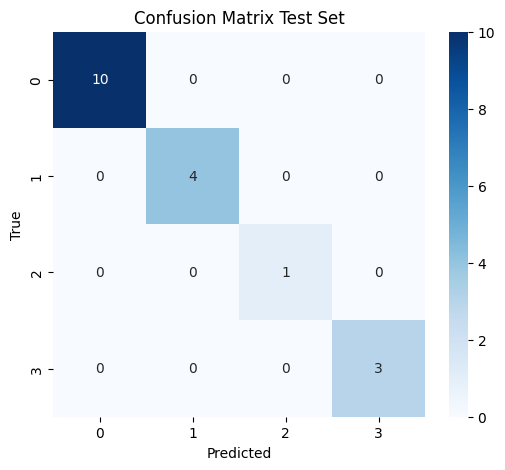

In [9]:
# ==============================
# STEP 8: Evaluasi Random Forest
# ==============================
def print_metrics(y_true, y_pred, dataset_name):
    print(f"\n--- Metrics {dataset_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred, average='macro'):.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Prediksi
y_pred_train = rf.predict(X_train_res)
y_pred_test = rf.predict(X_test)

# Print metrics
print_metrics(y_train_res, y_pred_train, "Train Set")
print_metrics(y_test, y_pred_test, "Test Set")

In [10]:
rf_model_path = "/content/drive/MyDrive/PhysioAnx/outputrf/fusionrfmodelfix_unknown.pkl"
joblib.dump(rf, rf_model_path)
print("Random Forest model tersimpan di:", rf_model_path)

Random Forest model tersimpan di: /content/drive/MyDrive/PhysioAnx/outputrf/fusionrfmodelfix_unknown.pkl


In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Load hasil fusion YOLO + DNN per nama
fusion_csv_out = "/content/drive/MyDrive/PhysioAnx/path_ke_output/fusionprobspername.csv"
fusion_df = pd.read_csv(fusion_csv_out, index_col=0)  # index_col=0 jika ada index di CSV
print("Fusion dataframe berhasil dimuat, jumlah baris:", len(fusion_df))
fusion_df.head()

Mounted at /content/drive
Fusion dataframe berhasil dimuat, jumlah baris: 86


,yolo_prob_class0,yolo_prob_class1,yolo_prob_class2,yolo_prob_class3,dnn_prob_class0,dnn_prob_class1,dnn_prob_class2,dnn_prob_class3,label
Nama,,,,,,,,,
A. Lutphan Khanip,0.177779,0.177779,0.466662,0.177779,7.689111e-04,9.992297e-01,1.974621e-07,1.242226e-06,1
AMANDA AYU RAMADLANI,0.467693,0.177436,0.177436,0.177436,9.999995e-01,3.987186e-07,4.715915e-20,1.229423e-22,0
ANISA,0.462102,0.179299,0.179299,0.179299,9.999999e-01,1.048352e-07,1.018085e-20,2.362096e-23,0
ARCHANGELA CAESARIA WINDARI,0.464857,0.178381,0.178381,0.178381,9.999999e-01,3.508221e-09,8.704266e-25,4.398129e-28,0
Adexza Fadhil Aulia,0.466234,0.177922,0.177922,0.177922,5.547003e-22,1.348234e-04,2.479238e-05,9.998405e-01,3


In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Features dan target
X = fusion_df.drop(columns="label")
y = fusion_df["label"]

# Split train/test dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cek jumlah sampel per kelas
class_counts = Counter(y_train)
print("Jumlah sampel per kelas sebelum SMOTE:", class_counts)

# Tentukan k_neighbors SMOTE yang aman
min_samples = min(class_counts.values())
k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1
print("k_neighbors untuk SMOTE:", k_neighbors)

# Oversampling dengan SMOTE
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Jumlah sampel per kelas setelah SMOTE:", Counter(y_train_res))

Jumlah sampel per kelas sebelum SMOTE: Counter({0: 37, 1: 17, 3: 9, 2: 5})
k_neighbors untuk SMOTE: 4
Jumlah sampel per kelas setelah SMOTE: Counter({0: 37, 1: 37, 2: 37, 3: 37})


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ================================
# Random Forest dengan Gini
# ================================
rf_gini = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    criterion="gini"
)
rf_gini.fit(X_train_res, y_train_res)
y_pred_gini = rf_gini.predict(X_test)

acc_gini = accuracy_score(y_test, y_pred_gini)
f1_gini = f1_score(y_test, y_pred_gini, average="weighted")

print("=== Random Forest (Gini) ===")
print(f"Accuracy: {acc_gini:.4f}")
print(f"F1-score: {f1_gini:.4f}")
print(classification_report(y_test, y_pred_gini))

# ================================
# Random Forest dengan Entropy
# ================================
rf_entropy = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    criterion="entropy"
)
rf_entropy.fit(X_train_res, y_train_res)
y_pred_entropy = rf_entropy.predict(X_test)

acc_entropy = accuracy_score(y_test, y_pred_entropy)
f1_entropy = f1_score(y_test, y_pred_entropy, average="weighted")

print("\n=== Random Forest (Entropy) ===")
print(f"Accuracy: {acc_entropy:.4f}")
print(f"F1-score: {f1_entropy:.4f}")
print(classification_report(y_test, y_pred_entropy))

# ================================
# Perbandingan hasil
# ================================
print("\n=== Perbandingan Singkat ===")
print(f"Gini     -> Accuracy: {acc_gini:.4f}, F1: {f1_gini:.4f}")
print(f"Entropy  -> Accuracy: {acc_entropy:.4f}, F1: {f1_entropy:.4f}")

=== Random Forest (Gini) ===
Accuracy: 1.0000
F1-score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


=== Random Forest (Entropy) ===
Accuracy: 1.0000
F1-score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



In [ ]:
import pandas as pd

# Load YOLO dan DNN probabilitas (pastikan sudah ada kolom 'Nama' dan 'label')
yolo_path = "/content/drive/MyDrive/PhysioAnx/path_ke_output/yoloprobswithnames2.xlsx"
dnn_path  = "/content/drive/MyDrive/PhysioAnx/path_ke_output/dnnprobslabeled2.xlsx"

df_yolo = pd.read_excel(yolo_path)
df_dnn  = pd.read_excel(dnn_path)

# Ambil kolom Nama dan label saja
yolo_labels = df_yolo[["Nama", "label"]].drop_duplicates()
dnn_labels  = df_dnn[["Nama", "label"]].drop_duplicates()

# Merge untuk cek nama yang sama
merged_labels = pd.merge(yolo_labels, dnn_labels, on="Nama", suffixes=("_yolo", "_dnn"))

# Cek label yang sama
merged_labels["label_match"] = merged_labels["label_yolo"] == merged_labels["label_dnn"]

# Jumlah nama yang sama & label sama
total_same_name = len(merged_labels)
total_same_label = merged_labels["label_match"].sum()

print(f"Jumlah Nama yang sama di YOLO & DNN: {total_same_name}")
print(f"Jumlah Nama dengan label yang sama: {total_same_label}")

# Hitung nama unik
unique_names = merged_check["Nama"].nunique()
print("Jumlah Nama unik yang sama di YOLO & DNN:", unique_names)

# Hitung jumlah nama unik dengan label sama
label_match_names = merged_check[merged_check["label_yolo"] == merged_check["label_dnn"]]["Nama"].nunique()
print("Jumlah Nama unik dengan label yang sama:", label_match_names)

Jumlah Nama yang sama di YOLO & DNN: 99
Jumlah Nama dengan label yang sama: 34
Jumlah Nama unik yang sama di YOLO & DNN: 58
Jumlah Nama unik dengan label yang sama: 20


In [ ]:
# ==============================
# STEP 0: Setup & Library Install
# ==============================
!pip install ultralytics scikit-learn imbalanced-learn seaborn matplotlib

# ==============================
# STEP 1: Import Library
# ==============================
import os
import re
import csv
import pandas as pd
import numpy as np
from google.colab import drive
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # untuk simpan model

# ==============================
# STEP 2: Mount Google Drive
# ==============================
drive.mount('/content/drive')

# ==============================
# STEP 3: Filter File YOLO (hapus data Kaggle sesuai aturan)
# ==============================
folder_path = "/content/drive/MyDrive/PhysioAnx/DATASETYOLO/images"
output_txt = "/content/drive/MyDrive/PhysioAnx/filtered_filesyolo3.txt"
output_csv = "/content/drive/MyDrive/PhysioAnx/filtered_filesyolo3.csv"

def filter_files(folder_path):
    files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
    kept = []
    for f in files:
        m = re.match(r'([A-Z]+)-\((\d+)\)\.png', f)
        if not m:
            continue
        prefix, num = m.group(1), int(m.group(2))
        # Filter rules
        if prefix == 'A' and 378 <= num <= 411:
            continue
        if prefix == 'ES' and 241 <= num <= 259:
            continue
        if prefix == 'D' and 272 <= num <= 335:
            continue
        if prefix == 'N' and (241 <= num <= 274 or 338 <= num <= 354 or 414 <= num <= 509):
            continue
        kept.append((prefix, num, f.replace(".png", "")))
    kept_sorted = sorted(kept, key=lambda x: (x[0], x[1]))
    return [f for _, _, f in kept_sorted]

all_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
print(f"Total file PNG dalam folder: {len(all_files)}")
kept_files = filter_files(folder_path)
with open(output_txt, "w") as txtfile:
    for fn in kept_files:
        txtfile.write(fn + "\n")
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Filename"])
    for fn in kept_files:
        writer.writerow([fn])
print(f"Jumlah file setelah filter: {len(kept_files)}")

In [ ]:
# ==============================
# STEP 4: Load YOLO Model & Ambil Probabilitas
# ==============================
yolo_model = YOLO("/content/drive/MyDrive/PhysioAnx/resource/yolomodel.pt")  # ganti path sesuai model

# Misal kita sudah punya prediksi YOLO probabilitas di CSV
yolo_probs = pd.read_csv("/content/drive/MyDrive/PhysioAnx/path_ke_output/yolo_probs_with_labels.csv")

# Classification report YOLO
y_pred = np.argmax(yolo_probs[["prob_class0","prob_class1","prob_class2","prob_class3"]].values, axis=1)
y_true = yolo_probs["label"].values
target_names = ["normal", "emotional stress", "anxiety", "depression"]
print("YOLO Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))
cm_yolo = confusion_matrix(y_true, y_pred)
print("YOLO Confusion Matrix:\n", cm_yolo)

# ==============================
# STEP 5: Gabungkan YOLO dengan Nama Subjek
# ==============================
mapping = pd.read_csv("/content/drive/MyDrive/PhysioAnx/path_ke_output/mapping_nama.csv")  # kolom: 'Nama', 'Format YOLO', ...
yolo_merged = pd.merge(mapping, yolo_probs, left_on="Format YOLO", right_on="filename", how="inner")
cols = ["Nama", "Format YOLO", "Label YOLO", "filename",
        "prob_class0", "prob_class1", "prob_class2", "prob_class3", "label"]
yolo_merged = yolo_merged[cols]
yolo_merged.to_csv("/content/drive/MyDrive/PhysioAnx/path_ke_output/yolo_probs_with_names.csv", index=False)
print("Selesai, file gabungan YOLO dengan Nama disimpan!")

# ==============================
# STEP 6: Load DNN Model & Dataset
# ==============================
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

dnn_model = load_model("/content/drive/MyDrive/PhysioAnx/path_ke_model/dnnmodel.h5")
scaler = joblib.load("/content/drive/MyDrive/PhysioAnx/path_ke_model/dnn_scaler.save")

df_dnn = pd.read_csv("/content/drive/MyDrive/PhysioAnx/path_ke_dataset/dnn_dataset.csv")
label_map = {"normal to mild":0, "mild to moderate":1, "moderate to severe":2, "severe":3}
df_dnn["label"] = df_dnn["KELAS"].map(label_map)

# ==============================
# STEP 7: Probabilitas DNN & Evaluasi
# ==============================
X_dnn = df_dnn.drop(columns=["KELAS","label","Nama"])
X_dnn_scaled = scaler.transform(X_dnn)
y_true_dnn = df_dnn["label"].values
y_pred_probs_dnn = dnn_model.predict(X_dnn_scaled)
y_pred_dnn = np.argmax(y_pred_probs_dnn, axis=1)

print("DNN Classification Report:")
print(classification_report(y_true_dnn, y_pred_dnn, target_names=list(label_map.keys())))
cm_dnn = confusion_matrix(y_true_dnn, y_pred_dnn)
print("DNN Confusion Matrix:\n", cm_dnn)

# ==============================
# STEP 8: Average Probabilitas per Nama (YOLO + DNN) & Gabungkan
# ==============================
# YOLO per nama
yolo_avg = yolo_merged.groupby("Nama")[["prob_class0","prob_class1","prob_class2","prob_class3"]].mean()
# DNN per nama
dnn_avg = pd.DataFrame(df_dnn.groupby("Nama")[["label"]].first())  # label utama
dnn_probs_avg = pd.DataFrame(df_dnn.groupby("Nama")[["prob_class0","prob_class1","prob_class2","prob_class3"]].mean())
# Tambahkan label utama
dnn_probs_avg["label"] = dnn_avg["label"]

# Sinkronisasi nama yang sama
common_names = yolo_avg.index.intersection(dnn_probs_avg.index)
fusion_df = pd.concat([yolo_avg.loc[common_names], dnn_probs_avg.loc[common_names].drop(columns="label")], axis=1)
fusion_df["label"] = dnn_probs_avg.loc[common_names, "label"]

fusion_csv = "/content/drive/MyDrive/PhysioAnx/path_ke_output/fusion_probs_per_name.csv"
fusion_df.to_csv(fusion_csv, index=True)
print(f"Hasil gabungan YOLO + DNN per nama disimpan: {fusion_csv}")

# ==============================
# STEP 9: Random Forest - Train/Test Split & Oversampling
# ==============================
X = fusion_df.drop(columns="label")
y = fusion_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Oversampling SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ==============================
# STEP 10: Train Random Forest
# ==============================
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_res, y_train_res)

# ==============================
# STEP 11: Evaluasi Random Forest
# ==============================
y_train_pred = rf.predict(X_train_res)
y_test_pred = rf.predict(X_test)

# Metrik
def print_metrics(y_true, y_pred, dataset_name):
    print(f"\n--- Metrics {dataset_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred, average='macro'):.4f}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

print_metrics(y_train_res, y_train_pred, "Train")
print_metrics(y_test, y_test_pred, "Test")

# ==============================
# STEP 12: Simpan Model Random Forest
# ==============================
rf_model_path = "/content/drive/MyDrive/PhysioAnx/outputrf/rf_fusion_model.pkl"
joblib.dump(rf, rf_model_path)
print(f"Random Forest model saved at: {rf_model_path}")

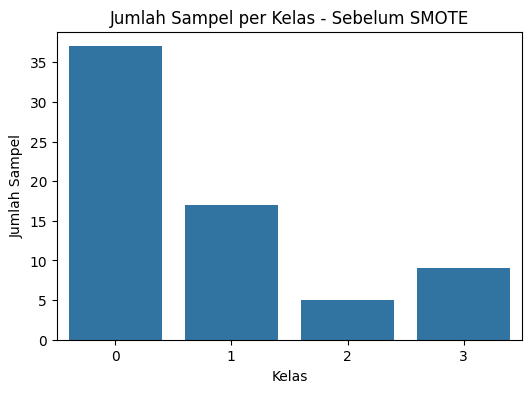

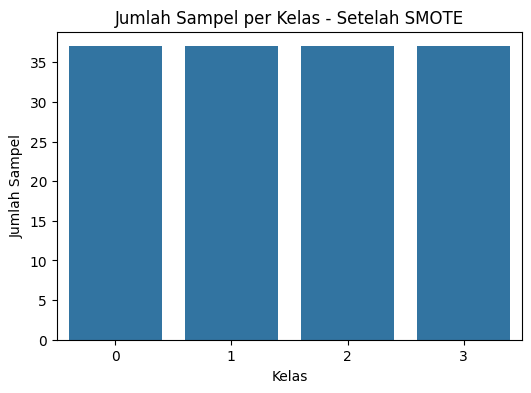

In [ ]:
# Visualisasi jumlah sampel per kelas sebelum dan sesudah SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Sebelum SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Jumlah Sampel per Kelas - Sebelum SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.show()

# Setelah SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res)
plt.title("Jumlah Sampel per Kelas - Setelah SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.show()

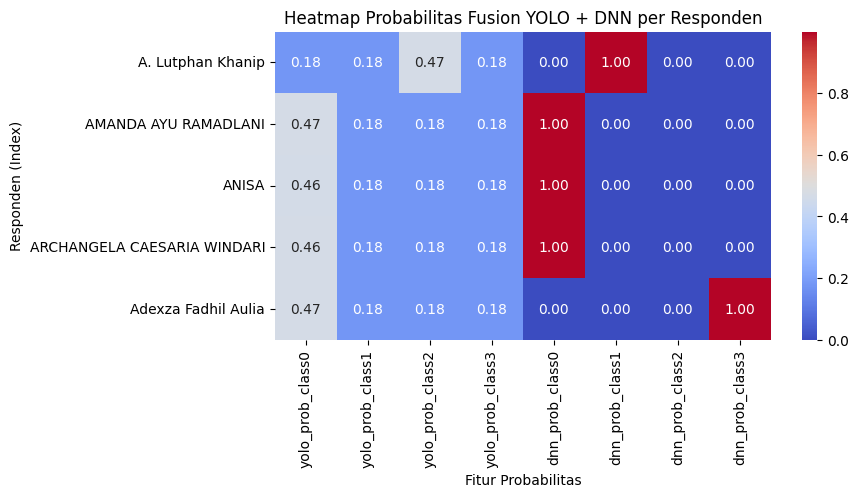

In [ ]:
# Contoh heatmap probabilitas untuk 5 responden pertama
subset = fusion_df.head(5)
prob_matrix = subset.drop(columns="label").values

plt.figure(figsize=(8,4))
sns.heatmap(prob_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            yticklabels=subset.index, xticklabels=subset.columns[:-1])
plt.title("Heatmap Probabilitas Fusion YOLO + DNN per Responden")
plt.xlabel("Fitur Probabilitas")
plt.ylabel("Responden (Index)")
plt.show()

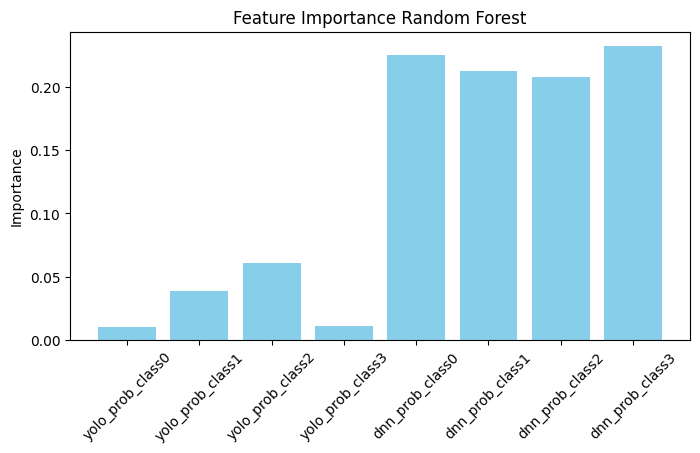

In [ ]:
importances = rf.feature_importances_
plt.figure(figsize=(8,4))
plt.bar(range(len(importances)), importances, color="skyblue")
plt.xticks(range(len(importances)), X.columns, rotation=45)
plt.title("Feature Importance Random Forest")
plt.ylabel("Importance")
plt.show()

In [ ]:
import os

# Train set confusion matrix
cm_train = confusion_matrix(y_train_res, y_pred_train)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Train Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("/content/drive/MyDrive/PhysioAnx/confusion_matrix_train.png")
plt.close()

# Test set confusion matrix
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("/content/drive/MyDrive/PhysioAnx/confusion_matrix_test.png")
plt.close()

In [ ]:
from scipy.stats import binomtest
from sklearn.metrics import f1_score, accuracy_score

# Akurasi
n = len(y_test)
k = (y_pred_test == y_test).sum()
akurasi = accuracy_score(y_test, y_pred_test)

# Uji Binomial untuk Akurasi
p_value_acc = binomtest(k, n, p=0.85, alternative='greater').pvalue

print(f"Akurasi test set: {akurasi:.4f}")
print(f"P-value uji binomial (Hipotesis 1): {p_value_acc:.6f}")

Akurasi test set: 1.0000
P-value uji binomial (Hipotesis 1): 0.053646


In [ ]:
# F1-score (macro)
f1 = f1_score(y_test, y_pred_test, average='macro')

# Bandingkan dengan threshold 0.85
if f1 >= 0.85:
    hasil_f1 = "H1 diterima (F1-score memenuhi ≥ 85%)"
else:
    hasil_f1 = "H0 diterima (F1-score < 85%)"

print(f"F1-score test set: {f1:.4f}")
print(f"Hasil pengujian Hipotesis 2: {hasil_f1}")

F1-score test set: 1.0000
Hasil pengujian Hipotesis 2: H1 diterima (F1-score memenuhi ≥ 85%)


In [ ]:
# Tampilkan 5 responden pertama dengan probabilitas YOLO, DNN, dan prediksi RF
fusion_df_example = fusion_df.head(5).copy()
fusion_df_example["Prediksi_RF"] = rf.predict(fusion_df_example.drop(columns="label"))
fusion_df_example

,yolo_prob_class0,yolo_prob_class1,yolo_prob_class2,yolo_prob_class3,dnn_prob_class0,dnn_prob_class1,dnn_prob_class2,dnn_prob_class3,label,Prediksi_RF
Nama,,,,,,,,,,
A. Lutphan Khanip,0.177779,0.177779,0.466662,0.177779,7.689111e-04,9.992297e-01,1.974621e-07,1.242226e-06,1,1
AMANDA AYU RAMADLANI,0.467693,0.177436,0.177436,0.177436,9.999995e-01,3.987186e-07,4.715915e-20,1.229423e-22,0,0
ANISA,0.462102,0.179299,0.179299,0.179299,9.999999e-01,1.048352e-07,1.018085e-20,2.362096e-23,0,0
ARCHANGELA CAESARIA WINDARI,0.464857,0.178381,0.178381,0.178381,9.999999e-01,3.508221e-09,8.704266e-25,4.398129e-28,0,0
Adexza Fadhil Aulia,0.466234,0.177922,0.177922,0.177922,5.547003e-22,1.348234e-04,2.479238e-05,9.998405e-01,3,3


In [ ]:
# ==============================
# Install & Import Library
# ==============================
!pip install ultralytics scikit-learn imbalanced-learn seaborn matplotlib tensorflow joblib

import os
import re
import pandas as pd
import numpy as np
from google.colab import drive
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import joblib
from collections import Counter

# ==============================
# Mount Google Drive
# ==============================
drive.mount('/content/drive')

# ==============================
# Load YOLO Model
# ==============================
YOLO_MODEL_PATH = "/content/drive/MyDrive/PhysioAnx/resource/yolomodel.pt"
yolo_model = YOLO(YOLO_MODEL_PATH)

images_dir = "/content/drive/MyDrive/PhysioAnx/DATASETYOLO/images"
labels_dir = "/content/drive/MyDrive/PhysioAnx/DATASETYOLO/labels"

# Filter file sesuai aturan
def filter_files_yolo(files):
    kept = []
    for f in files:
        m = re.match(r'([A-Z]+)-\((\d+)\)\.png', f)
        if not m: continue
        prefix, num = m.group(1), int(m.group(2))
        if prefix == 'A' and 378 <= num <= 411: continue
        if prefix == 'ES' and 241 <= num <= 259: continue
        if prefix == 'D' and 272 <= num <= 335: continue
        if prefix == 'N' and (241 <= num <= 274 or 338 <= num <= 354 or 414 <= num <= 509): continue
        kept.append(f)
    return kept

all_images = [f for f in os.listdir(images_dir) if f.endswith('.png')]
filtered_images = filter_files_yolo(all_images)

# ==============================
# YOLO Probabilitas dengan Unknown
# ==============================
def get_probs_yolo_detect(image_path, num_classes=4):
    results = yolo_model.predict(image_path, save=False, verbose=False, conf=0.25)[0]
    boxes = results.boxes
    vec = np.zeros(num_classes, dtype=np.float32)
    if boxes is not None and boxes.cls is not None and len(boxes.cls) > 0:
        classes = boxes.cls.cpu().numpy().astype(int)
        confs = boxes.conf.cpu().numpy()
        for c, s in zip(classes, confs):
            if 0 <= c < num_classes:
                vec[c] += s
        exp_vec = np.exp(vec)
        probs = exp_vec / exp_vec.sum()
        label = int(np.argmax(probs))
    else:
        probs = np.zeros(num_classes, dtype=np.float32)  # unknown
        label = -1
    return probs, label

def get_label_from_txt(txt_path):
    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            line = f.readline().strip().split()
            if len(line) > 0:
                return int(line[0])
    return -1

records = []
for fname in sorted(filtered_images):
    img_path = os.path.join(images_dir, fname)
    label_path = os.path.join(labels_dir, os.path.splitext(fname)[0] + ".txt")
    probs, pred_label = get_probs_yolo_detect(img_path, num_classes=4)
    true_label = get_label_from_txt(label_path)
    records.append([fname] + probs.tolist() + [pred_label, true_label])

df_yolo = pd.DataFrame(records, columns=["filename", "prob_class0", "prob_class1", "prob_class2", "prob_class3", "pred_label", "true_label"])
yolo_csv_out = "/content/drive/MyDrive/PhysioAnx/path_ke_output/yoloprobswithlabels_unknown.csv"
df_yolo.to_csv(yolo_csv_out, index=False)

# ==============================
# Load DNN Model
# ==============================
DNN_MODEL_PATH = "/content/drive/MyDrive/PhysioAnx/resource/dnnmodel.h5"
SCALER_PATH = "/content/drive/MyDrive/PhysioAnx/resource/scaler_joblibfold2.pkl"
DATASET_DNN_CSV = "/content/drive/MyDrive/PhysioAnx/resource/databersih3.csv"

dnn_model = load_model(DNN_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
dnn_model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

df_dnn = pd.read_csv(DATASET_DNN_CSV)
label_map = {"normal to mild":0,"mild to moderate":1,"moderate to severe":2,"severe":3}
df_dnn["label"] = df_dnn["KELAS"].map(label_map)

X_dnn = df_dnn[["HR","ST","GSR"]].values
X_scaled = scaler.transform(X_dnn)
y_dnn = df_dnn["label"].values
y_cat = to_categorical(y_dnn, num_classes=4)

# Probabilitas dengan aturan unknown
probs_dnn = dnn_model.predict(X_scaled)
probs_list, labels_list = [], []
for row in probs_dnn:
    if row.max() < 0.5:  # threshold unknown
        probs_list.append([0,0,0,0])
        labels_list.append(-1)
    else:
        probs_list.append(row.tolist())
        labels_list.append(int(np.argmax(row)))

probs_df_dnn = pd.DataFrame(probs_list, columns=[f"prob_class{i}" for i in range(4)])
df_out_dnn = pd.concat([df_dnn[["Nama","KELAS"]].reset_index(drop=True), probs_df_dnn], axis=1)
df_out_dnn["pred_label"] = labels_list
df_out_dnn["true_label"] = y_dnn

dnn_csv_out = "/content/drive/MyDrive/PhysioAnx/path_ke_output/dnnprobslabeled_unknown.csv"
df_out_dnn.to_csv(dnn_csv_out, index=False)

# ==============================
# Fusion YOLO + DNN
# ==============================
mapping_path = "/content/drive/MyDrive/PhysioAnx/path_ke_output/mapping_nama.csv"
mapping = pd.read_csv(mapping_path)
yolo_merged = pd.merge(mapping, df_yolo, left_on="Format YOLO", right_on="filename", how="inner")

yolo_avg = yolo_merged.groupby("Nama")[["prob_class0","prob_class1","prob_class2","prob_class3"]].mean()
dnn_avg = df_out_dnn.groupby("Nama")[["prob_class0","prob_class1","prob_class2","prob_class3"]].mean()
dnn_labels = df_out_dnn.groupby("Nama")["pred_label"].first()

common_names = yolo_avg.index.intersection(dnn_avg.index)
fusion_df = pd.concat([
    yolo_avg.loc[common_names].add_prefix("yolo_"),
    dnn_avg.loc[common_names].add_prefix("dnn_")
], axis=1)
fusion_df["label"] = dnn_labels.loc[common_names]

# Tandai unknown jika salah satu unknown
fusion_df["label"] = fusion_df["label"].apply(lambda x: -1 if x == -1 else x)

fusion_csv_out = "/content/drive/MyDrive/PhysioAnx/path_ke_output/fusionprobspername_unknown.csv"
fusion_df.to_csv(fusion_csv_out, index=True)

# ==============================
# Train/Test Split + Random Forest
# ==============================
X = fusion_df.drop(columns="label")
y = fusion_df["label"]

# Hanya gunakan data selain unknown untuk training
mask = y != -1
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class_counts = Counter(y_train)
min_samples = min(class_counts.values())
k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train_res, y_train_res)

# Evaluasi
def print_metrics(y_true, y_pred, dataset_name):
    print(f"\n--- Metrics {dataset_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

y_pred_train = rf.predict(X_train_res)
y_pred_test = rf.predict(X_test)

print_metrics(y_train_res, y_pred_train, "Train Set")
print_metrics(y_test, y_pred_test, "Test Set")

# Simpan Model
rf_model_path = "/content/drive/MyDrive/PhysioAnx/outputrf/fusionrfmodel_unknown.pkl"
joblib.dump(rf, rf_model_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.5 MB/s eta 0:00:00


KeyboardInterrupt: 